# Modelo de classificação de contratação de graduandos

In [90]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from pickle import dump

## 1) Importação de dados

In [ ]:
url_dados = 'https://github.com/andersonyama/contratacao-estudantes/raw/refs/heads/main/student-placement-dataset.zip'
labels = ['ramo', 'rank_universidade', 'cgpa', 'reprovacoes', 'coding_skills',
       'dsa_score', 'aptitude_score', 'communication_skills', 'ml_knowledge',
       'system_design', 'internships', 'projects_count', 'certifications',
       'hackathons', 'open_source_contributions', 'extracurriculars',
       'contratado','salario']

In [48]:
df_estudantes = pd.read_csv(url_dados, names=labels, header=0)
df_estudantes.head()

,ramo,rank_universidade,cgpa,reprovacoes,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,contratado,salario
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42


## 2) Tratamento de dados

In [50]:
df_tratado = df_estudantes.copy()

# transforma o ranking para número
df_tratado['rank_universidade'] = df_tratado['rank_universidade'].str.slice(5,6).astype(int)

# traduz o ramo e cria dummies para cada um dos ramos
traducao_ramo = {
    "CSE":"computacao",
    "ECE":"eletronica",
    "ME":"mecanica",
    "CE":"civil",
    "EE":"eletrica",
    "IT":"informatica",
    "Chemical": "quimica"
}
df_tratado['ramo'] = df_tratado['ramo'].map(traducao_ramo)
df_tratado = pd.get_dummies(df_tratado, prefix=['eng'], columns=['ramo'])


In [51]:
df_tratado.head()

,rank_universidade,cgpa,reprovacoes,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,...,extracurriculars,contratado,salario,eng_civil,eng_computacao,eng_eletrica,eng_eletronica,eng_informatica,eng_mecanica,eng_quimica
0,3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,...,1,1,14.75,False,False,False,True,False,False,False
1,2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,...,0,0,NaN,False,False,False,False,False,False,True
2,2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,...,0,1,19.06,False,False,True,False,False,False,False
3,2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,...,0,0,NaN,True,False,False,False,False,False,False
4,2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,...,1,1,13.42,False,True,False,False,False,False,False


## 3) Escolha de atributos preditores

In [56]:
atributos_preditores_potenciais = [col for col in df_tratado.columns if col not in ['contratado','salario']]

X_potenciais = df_tratado[atributos_preditores_potenciais]
Y = df_tratado['contratado']

<Axes: >

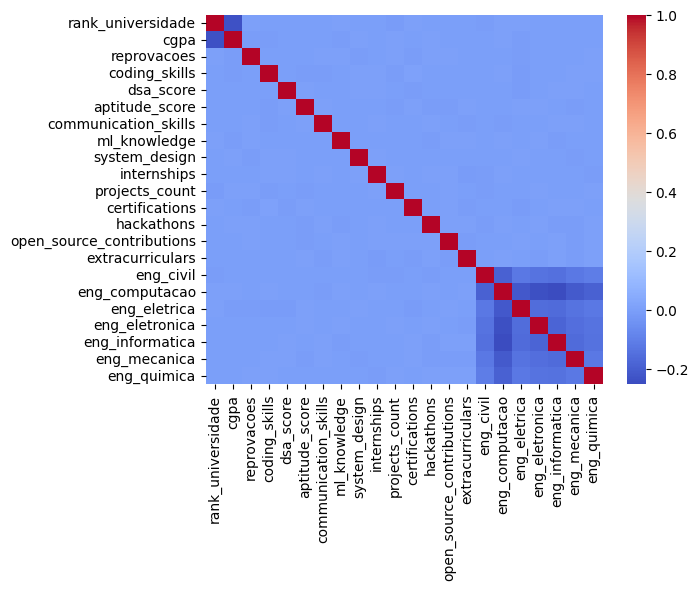

In [57]:
# avaliação de correlação entre as variáveis explicativas para evitar redundâncias
sns.heatmap(X_potenciais.corr(), cmap="coolwarm")

Dado que não existem correlações relevantes entre as variáveis, não será excluída nenhum atributo por esse critério.

---

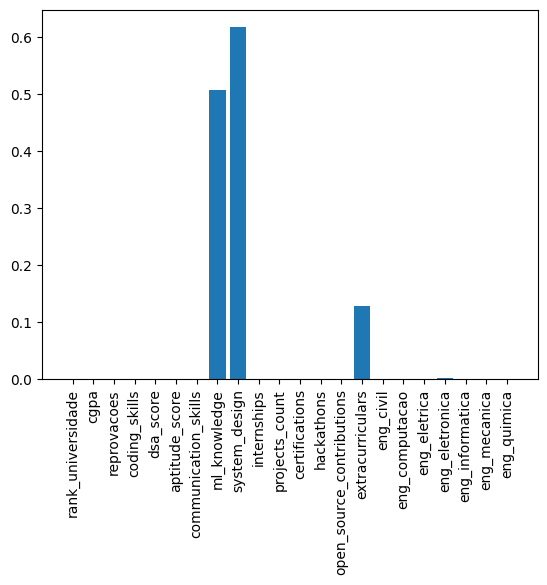

In [59]:
estatisticas_F, p_valores = f_classif(X_potenciais, Y)

bars = plt.bar(atributos_preditores_potenciais,p_valores)
plt.tick_params(axis='x', rotation=90)

In [11]:
atributos_remover = ['ml_knowledge','system_design','extracurriculars']
atributos_preditores_potenciais = [atr for atr in atributos_preditores_potenciais if atr not in atributos_remover]
X_potenciais = X_potenciais.drop(atributos_remover,axis=1)

Dados os p-valores altos, foram excluídos do modelo os atributos `ml_knowledge`, `system_design` e `extracurriculars`.

---

In [ ]:
# seleção automática das 5 melhores variáveis, à partir do teste F
seletor_f_classif = SelectKBest(f_classif, k=5)
seletor_f_classif.set_output(transform='pandas')
X_selecionados_f_classif = seletor_f_classif.fit_transform(X_potenciais,Y)

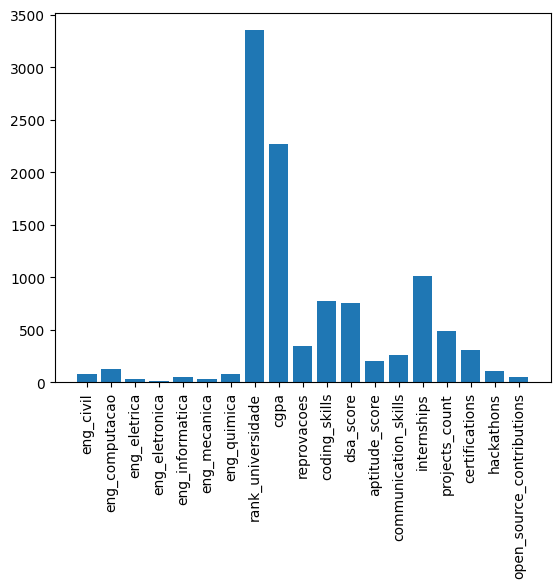

In [ ]:
plt.bar(atributos_preditores_potenciais,seletor_f_classif.scores_)
plt.tick_params(axis='x', rotation=90)

In [64]:
X_selecionados_f_classif

,rank_universidade,cgpa,coding_skills,dsa_score,internships
0,3,6.70,7.6,4.4,1
1,2,5.70,5.4,7.9,0
2,2,7.19,5.6,6.8,1
3,2,6.48,5.2,3.1,1
4,2,6.71,5.9,4.7,1
...,...,...,...,...,...
99995,3,6.08,3.1,5.4,2
99996,3,7.46,4.8,6.8,1
99997,2,7.94,4.9,9.1,0
99998,3,6.63,5.0,8.0,1


Dessa forma, foram selecionados os atributos `rank_universidade`, `cgpa`, `coding_skills`, `dsa_score` e `internships`.

## 4) Configurações e separação em grupo de treino e teste

In [70]:
tamanho_teste = 0.2
seed = 11
avaliacao = 'accuracy'

atributos_preditores = ['rank_universidade','cgpa','coding_skills','dsa_score','internships']
X = df_tratado[atributos_preditores]

In [71]:
# Separação em grupo de treino e teste
X_treino, X_teste, Y_treino, Y_teste = train_test_split(X, Y,
                                                        test_size=tamanho_teste,
                                                        shuffle=True,
                                                        random_state=seed,
                                                        stratify=Y)

In [72]:
# Configurações de particionamento
num_particoes = 10
kfold = StratifiedKFold(n_splits=num_particoes, shuffle=True, random_state=seed)

## Modelagem

KNN: 0.647463 (0.001945)
ArvDec: 0.591913 (0.004460)
NB: 0.691650 (0.003468)
RegLog: 0.692612 (0.003147)


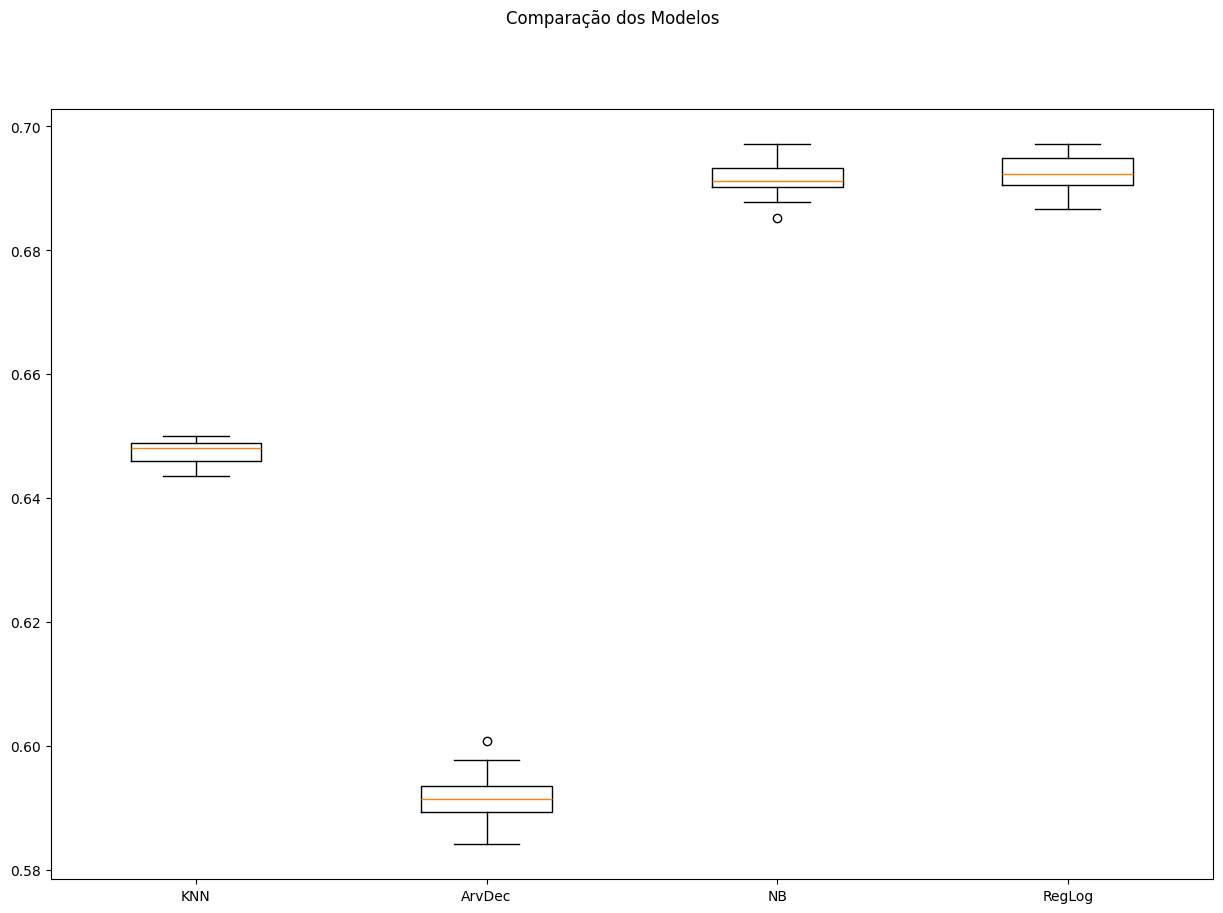

In [73]:
np.random.seed(seed) # definindo uma semente global

# Lista que armazenará os modelos
modelos = []

# Criando os modelos e adicionando-os na lista de modelos
modelos.append(('KNN', KNeighborsClassifier()))
modelos.append(('ArvDec', DecisionTreeClassifier()))
modelos.append(('NB', GaussianNB()))
modelos.append(('RegLog', LogisticRegression()))

# Listas para armazenar os resultados
resultados_validacao_cruzada = []
nomes_modelos = []

# Avaliação dos modelos
for nome_modelo, modelo in modelos:
    resultado_validacao_cruzada = cross_val_score(modelo, X_treino, Y_treino, cv=kfold, scoring=avaliacao)
    resultados_validacao_cruzada.append(resultado_validacao_cruzada)
    nomes_modelos.append(nome_modelo)
    msg = "%s: %f (%f)" % (nome_modelo, resultado_validacao_cruzada.mean(), resultado_validacao_cruzada.std())
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(15,10))
fig.suptitle('Comparação dos Modelos')
ax = fig.add_subplot(111)
plt.boxplot(resultados_validacao_cruzada)
ax.set_xticklabels(nomes_modelos)
plt.show()

In [85]:
# Tuning do KNN para verificar validade do modelo

np.random.seed(seed) # definindo uma semente global para este bloco

pipelines = []

# Definindo os componentes do pipeline
knn = ('KNN', KNeighborsClassifier())
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

pipelines.append(('knn-orig', Pipeline(steps=[knn])))
pipelines.append(('knn-padr', Pipeline(steps=[standard_scaler, knn])))
pipelines.append(('knn-norm', Pipeline(steps=[min_max_scaler, knn])))

param_grid = {
    'KNN__n_neighbors': [1,3,5,7,9,11,13,15],
    'KNN__metric': ["euclidean", "manhattan", "minkowski"],
}

# Prepara e executa o GridSearchCV
for name, model in pipelines:
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=avaliacao, cv=kfold)
    grid.fit(X_treino, Y_treino)
    # imprime a melhor configuração
    print("Sem tratamento de missings: %s - Melhor: %f usando %s" % (name, grid.best_score_, grid.best_params_))     


Sem tratamento de missings: knn-orig - Melhor: 0.673312 usando {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 15}
Sem tratamento de missings: knn-padr - Melhor: 0.673125 usando {'KNN__metric': 'euclidean', 'KNN__n_neighbors': 15}
Sem tratamento de missings: knn-norm - Melhor: 0.673550 usando {'KNN__metric': 'euclidean', 'KNN__n_neighbors': 15}


Devido a diferença relevante de resultado entre os modelos, mesmo considerando o KNN ajustado, vamos analisar apenas os modelos Naive-Bayes e de Regressão Logística para normalização e padronização.

NB-orig: 0.692 (0.003)
NB-padr: 0.692 (0.003)
NB-norm: 0.692 (0.003)
RegLog-orig: 0.693 (0.003)
RegLog-padr: 0.693 (0.003)
RegLog-norm: 0.693 (0.003)


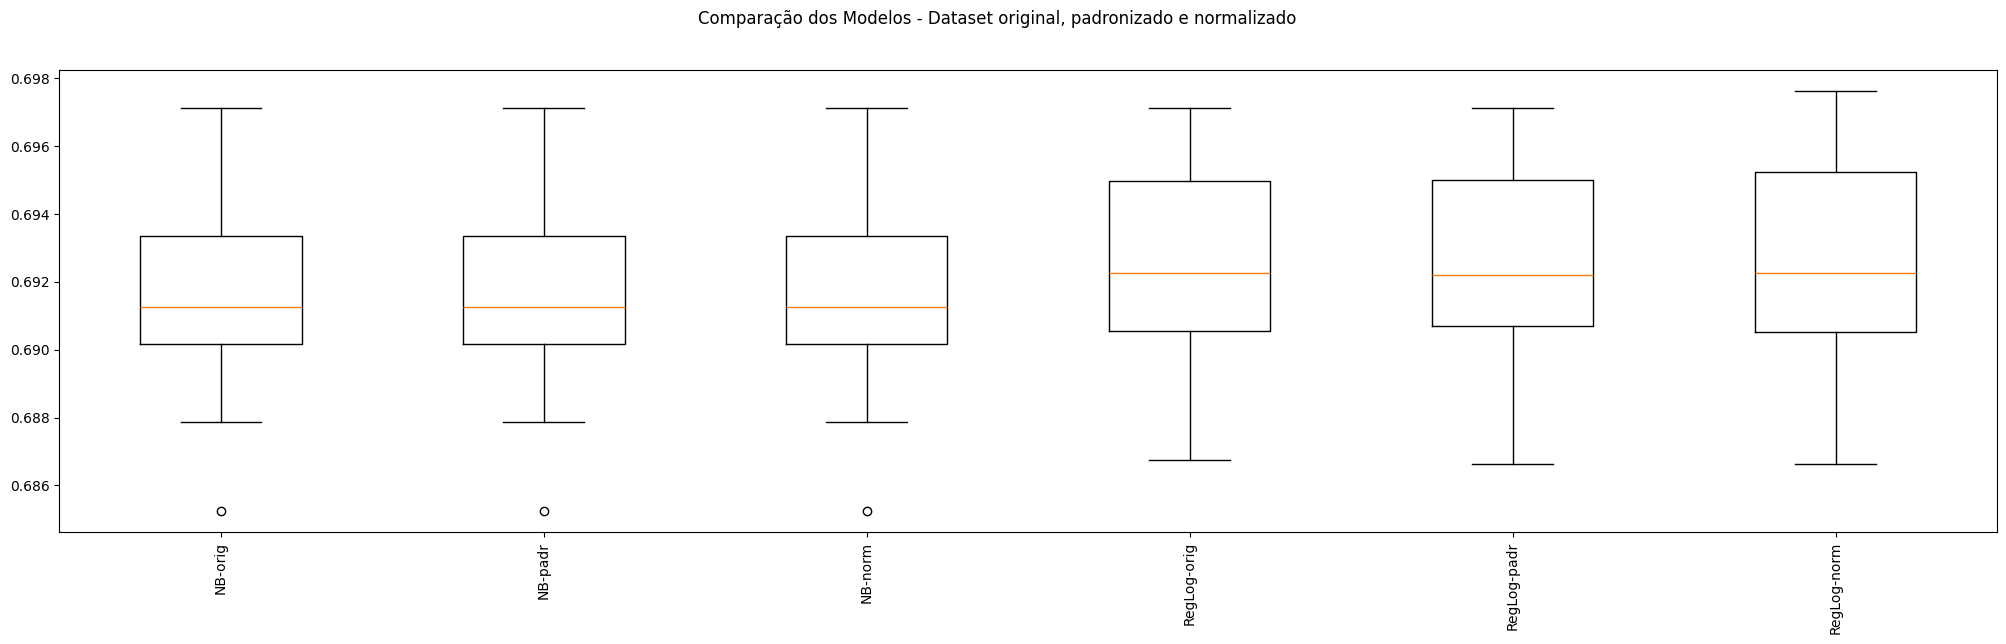

In [86]:
np.random.seed(seed) # definindo uma semente global para este bloco

# Listas para armazenar os armazenar os pipelines e os resultados para todas as visões do dataset
pipelines = []
resultados_pipelines = []
nomes_pipelines = []

# Criando os elementos do pipeline

# Algoritmos que serão utilizados
naive_bayes = ('NB', GaussianNB())
regressao_logistica = ('RegLog', LogisticRegression())

# Transformações que serão utilizadas
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

# Montando os pipelines

# Modelo Naive-Bayes
pipelines.append(('NB-orig', Pipeline([naive_bayes]))) # Dataset original
pipelines.append(('NB-padr', Pipeline([standard_scaler, naive_bayes]))) # Dataset Padronizado
pipelines.append(('NB-norm', Pipeline([min_max_scaler, naive_bayes]))) # Dataset Normalizado

# Modelo Regressão Logística
pipelines.append(('RegLog-orig', Pipeline([regressao_logistica]))) # Dataset original
pipelines.append(('RegLog-padr', Pipeline([standard_scaler, regressao_logistica]))) # Dataset Padronizado
pipelines.append(('RegLog-norm', Pipeline([min_max_scaler, regressao_logistica]))) # Dataset Normalizado

# Executando os pipelines
for name, model in pipelines:
    resultado_validacao_cruzada = cross_val_score(model, X_treino, Y_treino, cv=kfold, scoring=avaliacao)
    resultados_pipelines.append(resultado_validacao_cruzada)
    nomes_pipelines.append(name)
    msg = "%s: %.3f (%.3f)" % (name, resultado_validacao_cruzada.mean(), resultado_validacao_cruzada.std()) # formatando para 3 casas decimais
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(25,6))
fig.suptitle('Comparação dos Modelos - Dataset original, padronizado e normalizado')
ax = fig.add_subplot(111)
plt.boxplot(resultados_pipelines)
ax.set_xticklabels(nomes_pipelines, rotation=90)
plt.show()

Dada a pequena diferença de resultados, podemos considerar quase equivalentes todos os modelos. Vamos definir como final o modelo de Naive Bayes sem normalização ou padronização, por apresentar um boxplot mais concentro ao redor da mediana.

## Finalização do Modelo

In [88]:
# Avaliação do modelo com o conjunto de testes

# Preparação do modelo
model = GaussianNB()
model.fit(X_treino, Y_treino)

# Estimativa da acurácia no conjunto de teste
predictions = model.predict(X_teste)
print(accuracy_score(Y_teste, predictions))

0.68935


In [89]:
# Preparação do modelo com TODO o dataset
model.fit(X, Y)

GaussianNB()

In [91]:
# Exporta o modelo para uso em aplicação externa
filename = 'modelo_contratacao_estudantes.pkl'
dump(modelo, open(filename, 'wb'))

# Referência

https://www.kaggle.com/datasets/suhanigupta04/student-placement-prediction-dataset/data